In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import joblib

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
customers = pd.read_csv(
    "../data/raw/customers.csv"
)

restaurants = pd.read_csv(
    "../data/raw/restaurants.csv"
)

orders = pd.read_csv(
    "../data/raw/orders.csv"
)

deliveries = pd.read_csv(
    "../data/raw/deliveries.csv"
)

reviews = pd.read_csv(
    "../data/raw/reviews.csv"
)

print("Raw datasets loaded successfully.")

print("Customers:", customers.shape)
print("Restaurants:", restaurants.shape)
print("Orders:", orders.shape)
print("Deliveries:", deliveries.shape)
print("Reviews:", reviews.shape)

Raw datasets loaded successfully.
Customers: (1000, 6)
Restaurants: (100, 6)
Orders: (5000, 10)
Deliveries: (5000, 7)
Reviews: (5000, 5)


In [4]:
import os

print("Processed files:")

for file in os.listdir("../data/processed"):
    print(file)

Processed files:
delivery_time_features.csv
customer_segmentation_features.csv
hourly_demand.csv
final_demand_forecast.csv
reviews_cleaned_sentiment.csv
demand_model_comparison.csv


In [5]:
customer_features = pd.read_csv(
    "../data/processed/customer_segmentation_features.csv"
)

delivery_features = pd.read_csv(
    "../data/processed/delivery_time_features.csv"
)

reviews_cleaned = pd.read_csv(
    "../data/processed/reviews_cleaned_sentiment.csv"
)

hourly_demand = pd.read_csv(
    "../data/processed/hourly_demand.csv"
)

final_forecast = pd.read_csv(
    "../data/processed/final_demand_forecast.csv"
)

model_comparison = pd.read_csv(
    "../data/processed/demand_model_comparison.csv"
)

print("Processed datasets loaded successfully.")

print("\nCustomer features:", customer_features.shape)
print("Delivery features:", delivery_features.shape)
print("Reviews:", reviews_cleaned.shape)
print("Hourly demand:", hourly_demand.shape)
print("Final forecast:", final_forecast.shape)
print("Demand model comparison:", model_comparison.shape)

Processed datasets loaded successfully.

Customer features: (992, 13)
Delivery features: (4665, 22)
Reviews: (5000, 8)
Hourly demand: (4344, 2)
Final forecast: (24, 2)
Demand model comparison: (2, 3)


In [6]:
print(customer_features.columns.tolist())
print()
print(customer_features.head())

['customer_id', 'total_orders', 'average_order_value', 'total_spending', 'weekend_orders', 'late_night_orders', 'active_months_x', 'ordering_frequency', 'active_months_y', 'average_rating_given', 'cluster', 'cluster_name', 'dbscan_cluster']

  customer_id  total_orders  average_order_value  total_spending  \
0   CUST_0001             5           157.950000          789.75   
1   CUST_0002             3           125.346667          376.04   
2   CUST_0003             3           194.970000          584.91   
3   CUST_0004             3           280.410000          841.23   
4   CUST_0005             2           148.730000          297.46   

   weekend_orders  late_night_orders  active_months_x  ordering_frequency  \
0               2                  2         5.466667            0.914634   
1               1                  1         2.300000            1.304348   
2               0                  1         1.366667            2.195122   
3               1                  1     

In [9]:
print(delivery_features.columns.tolist())
print()
print(delivery_features.head())

['order_id', 'customer_id', 'restaurant_id', 'order_timestamp', 'order_amount', 'number_of_items', 'weather', 'traffic_condition', 'order_status', 'preparation_time_minutes_order', 'delivery_id', 'driver_id', 'delivery_distance_km', 'preparation_time_minutes_delivery', 'delivery_time_minutes', 'tip_amount', 'category', 'rating', 'hour', 'day_of_week', 'is_weekend', 'time_of_day']

    order_id customer_id restaurant_id      order_timestamp  order_amount  \
0  ORD_00001   CUST_0785      REST_025  2026-05-10 00:04:01        100.00   
1  ORD_00002   CUST_0894      REST_066  2026-04-30 05:33:18        396.77   
2  ORD_00003   CUST_0776      REST_100  2026-02-03 10:44:48        197.80   
3  ORD_00004   CUST_0569      REST_018  2026-05-17 07:27:57        145.79   
4  ORD_00005   CUST_0298      REST_005  2026-05-21 01:33:11        147.25   

   number_of_items weather traffic_condition order_status  \
0                1  Cloudy            Medium    Delivered   
1                1  Cloudy     

In [7]:
print(reviews_cleaned.columns.tolist())
print()
print(reviews_cleaned.head())

['review_id', 'order_id', 'customer_id', 'rating', 'review_text', 'cleaned_review', 'sentiment', 'vader_sentiment']

   review_id   order_id customer_id  rating  \
0  REV_00001  ORD_00001   CUST_0785       3   
1  REV_00002  ORD_00002   CUST_0894       3   
2  REV_00003  ORD_00003   CUST_0776       2   
3  REV_00004  ORD_00004   CUST_0569       2   
4  REV_00005  ORD_00005   CUST_0298       3   

                                  review_text                 cleaned_review  \
0  Food was okay but delivery took some time.   food okay delivery took time   
1  Food was okay but delivery took some time.   food okay delivery took time   
2     Very slow delivery and poor experience.  slow delivery poor experience   
3                          Food arrived late.              food arrived late   
4                         Average experience.             average experience   

  sentiment vader_sentiment  
0   neutral        positive  
1   neutral        positive  
2  negative        negative  

In [8]:
print("Demand Model Comparison:")
print(model_comparison)

print("\nFinal Forecast:")
print(final_forecast.head())

Demand Model Comparison:
     Model       MAE      RMSE
0    ARIMA  0.794596  1.075318
1  Prophet  0.792507  1.079495

Final Forecast:
            Unnamed: 0  predicted_order_count
0  2026-05-25 19:00:00               1.079714
1  2026-05-25 20:00:00               1.076534
2  2026-05-25 21:00:00               1.076859
3  2026-05-25 22:00:00               1.076826
4  2026-05-25 23:00:00               1.076829


In [10]:
customer_segment_summary = (
    customer_features
    .groupby(["cluster", "cluster_name"])
    .agg(
        customers=("customer_id", "count"),
        total_orders=("total_orders", "sum"),
        avg_order_value=("average_order_value", "mean"),
        avg_total_spending=("total_spending", "mean"),
        avg_rating=("average_rating_given", "mean"),
        avg_weekend_orders=("weekend_orders", "mean"),
        avg_late_night_orders=("late_night_orders", "mean")
    )
    .reset_index()
)

print(customer_segment_summary)

   cluster                      cluster_name  customers  total_orders  \
0        0  Regular Moderate-Value Customers        413          1760   
1        1           Premium Frequent Diners        314          2393   
2        2    Occasional Low-Spend Customers        265           847   

   avg_order_value  avg_total_spending  avg_rating  avg_weekend_orders  \
0       212.474855          893.075109    3.159328            1.203390   
1       224.972036         1693.738057    3.208933            2.350318   
2       211.711665          677.593019    3.226294            0.860377   

   avg_late_night_orders  
0               1.314770  
1               2.805732  
2               1.011321  


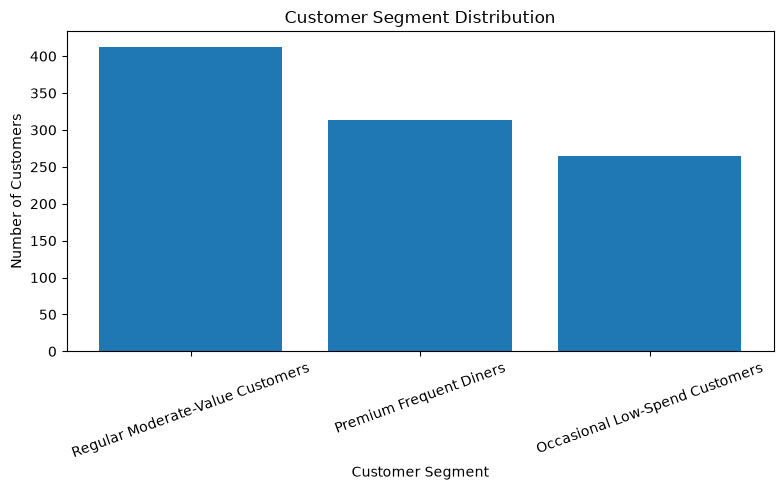

In [11]:
plt.figure(figsize=(8, 5))

plt.bar(
    customer_segment_summary["cluster_name"],
    customer_segment_summary["customers"]
)

plt.title("Customer Segment Distribution")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

In [12]:
sentiment_summary = (
    reviews_cleaned["sentiment"]
    .value_counts()
)

print("Sentiment Distribution:")
print(sentiment_summary)

print("\nSentiment Percentage:")
print(
    reviews_cleaned["sentiment"]
    .value_counts(normalize=True).mul(100).round(2)
)

Sentiment Distribution:
sentiment
neutral     2040
positive    1867
negative    1093
Name: count, dtype: int64

Sentiment Percentage:
sentiment
neutral     40.80
positive    37.34
negative    21.86
Name: proportion, dtype: float64


In [13]:
negative_reviews = reviews_cleaned[
    reviews_cleaned["sentiment"] == "negative"
]

print("Number of negative reviews:", len(negative_reviews))

print("\nNegative review examples:")
print(
    negative_reviews[
        ["rating", "review_text"]
    ].head(10)
)

Number of negative reviews: 1093

Negative review examples:
    rating                                review_text
2        2    Very slow delivery and poor experience.
3        2                         Food arrived late.
5        1                         Food arrived late.
7        2                The delivery took too long.
9        2                The delivery took too long.
12       2  Delivery was very late and food was cold.
16       2                The delivery took too long.
19       2                The delivery took too long.
22       2    Order was delayed and food was not hot.
32       2                         Food arrived late.


In [14]:
delivery_summary = delivery_features[
    [
        "delivery_time_minutes",
        "delivery_distance_km",
        "order_amount",
        "number_of_items",
        "preparation_time_minutes_order",
        "rating"
    ]
].describe()

print(delivery_summary)

       delivery_time_minutes  delivery_distance_km  order_amount  \
count            4665.000000           4665.000000   4665.000000   
mean               63.241801              4.980358    216.248875   
std                17.409925              3.158226    126.571160   
min                19.400000              0.500000    100.000000   
25%                51.100000              2.630000    125.750000   
50%                62.200000              4.280000    183.150000   
75%                73.700000              6.680000    265.710000   
max               137.600000             20.000000   2129.190000   

       number_of_items  preparation_time_minutes_order       rating  
count      4665.000000                     4665.000000  4665.000000  
mean          3.471811                       24.732905     4.116806  
std           1.719287                        8.309117     0.486482  
min           1.000000                        5.000000     3.000000  
25%           2.000000               

In [15]:
traffic_delivery = (
    delivery_features
    .groupby("traffic_condition")["delivery_time_minutes"]
    .mean()
    .sort_values(ascending=False)
)

print("Average delivery time by traffic condition:")
print(traffic_delivery)

Average delivery time by traffic condition:
traffic_condition
High      73.298984
Medium    62.590653
Low       55.662797
Name: delivery_time_minutes, dtype: float64


In [16]:
weather_delivery = (
    delivery_features
    .groupby("weather")["delivery_time_minutes"]
    .mean()
    .sort_values(ascending=False)
)

print("Average delivery time by weather:")
print(weather_delivery)

Average delivery time by weather:
weather
Heavy Rain    74.282488
Rain          67.802164
Cloudy        63.009648
Clear         60.666905
Name: delivery_time_minutes, dtype: float64


In [17]:
print("Demand Forecasting Model Comparison")
print(model_comparison)

Demand Forecasting Model Comparison
     Model       MAE      RMSE
0    ARIMA  0.794596  1.075318
1  Prophet  0.792507  1.079495


In [18]:
final_forecast = final_forecast.rename(
    columns={
        "Unnamed: 0": "timestamp"
    }
)

final_forecast["timestamp"] = pd.to_datetime(
    final_forecast["timestamp"]
)

print(final_forecast.head())
print("\nForecast observations:", len(final_forecast))

            timestamp  predicted_order_count
0 2026-05-25 19:00:00               1.079714
1 2026-05-25 20:00:00               1.076534
2 2026-05-25 21:00:00               1.076859
3 2026-05-25 22:00:00               1.076826
4 2026-05-25 23:00:00               1.076829

Forecast observations: 24


In [19]:
print(
    "Average predicted demand:",
    final_forecast["predicted_order_count"].mean()
)

print(
    "Maximum predicted demand:",
    final_forecast["predicted_order_count"].max()
)

print(
    "Minimum predicted demand:",
    final_forecast["predicted_order_count"].min()
)

Average predicted demand: 1.0769377658055943
Maximum predicted demand: 1.0797141608713945
Minimum predicted demand: 1.07653406105562


In [20]:
integrated_summary = pd.DataFrame({
    "Component": [
        "Customer Segmentation",
        "Sentiment Analysis",
        "Delivery Time Prediction",
        "Demand Forecasting"
    ],
    "Approach": [
        "K-Means + DBSCAN",
        "TF-IDF + Naive Bayes + VADER",
        "Linear Regression / Random Forest",
        "ARIMA + Prophet"
    ],
    "Purpose": [
        "Identify customer groups",
        "Identify customer satisfaction patterns",
        "Predict delivery time",
        "Forecast future demand"
    ]
})

print(integrated_summary)

                  Component                           Approach  \
0     Customer Segmentation                   K-Means + DBSCAN   
1        Sentiment Analysis       TF-IDF + Naive Bayes + VADER   
2  Delivery Time Prediction  Linear Regression / Random Forest   
3        Demand Forecasting                    ARIMA + Prophet   

                                   Purpose  
0                 Identify customer groups  
1  Identify customer satisfaction patterns  
2                    Predict delivery time  
3                   Forecast future demand  


In [21]:
most_valuable_segment = customer_segment_summary.loc[
    customer_segment_summary["avg_total_spending"].idxmax()
]

print("Most valuable customer segment:")
print(most_valuable_segment)

Most valuable customer segment:
cluster                                        1
cluster_name             Premium Frequent Diners
customers                                    314
total_orders                                2393
avg_order_value                       224.972036
avg_total_spending                   1693.738057
avg_rating                              3.208933
avg_weekend_orders                      2.350318
avg_late_night_orders                   2.805732
Name: 1, dtype: object


In [22]:
highest_volume_segment = customer_segment_summary.loc[
    customer_segment_summary["total_orders"].idxmax()
]

print("Highest order-volume customer segment:")
print(highest_volume_segment)

Highest order-volume customer segment:
cluster                                        1
cluster_name             Premium Frequent Diners
customers                                    314
total_orders                                2393
avg_order_value                       224.972036
avg_total_spending                   1693.738057
avg_rating                              3.208933
avg_weekend_orders                      2.350318
avg_late_night_orders                   2.805732
Name: 1, dtype: object


In [23]:
negative_rate = (
    (reviews_cleaned["sentiment"] == "negative").mean() * 100
)

print(
    f"Negative customer review rate: {negative_rate:.2f}%"
)

Negative customer review rate: 21.86%


In [24]:
traffic_risk = (
    delivery_features
    .groupby("traffic_condition")["delivery_time_minutes"]
    .mean()
    .sort_values(ascending=False)
)

highest_traffic_risk = traffic_risk.index[0]

print(
    f"Highest delivery-time risk condition: "
    f"{highest_traffic_risk}"
)

print(
    f"Average delivery time: "
    f"{traffic_risk.iloc[0]:.2f} minutes"
)

Highest delivery-time risk condition: High
Average delivery time: 73.30 minutes


In [25]:
weather_risk = (
    delivery_features
    .groupby("weather")["delivery_time_minutes"]
    .mean()
    .sort_values(ascending=False)
)

highest_weather_risk = weather_risk.index[0]

print(
    f"Highest weather-related delivery risk: "
    f"{highest_weather_risk}"
)

print(
    f"Average delivery time: "
    f"{weather_risk.iloc[0]:.2f} minutes"
)

Highest weather-related delivery risk: Heavy Rain
Average delivery time: 74.28 minutes


In [26]:
high_traffic_time = traffic_risk.loc["High"]
low_traffic_time = traffic_risk.loc["Low"]

traffic_difference = high_traffic_time - low_traffic_time

print(
    f"High traffic delivery time: "
    f"{high_traffic_time:.2f} minutes"
)

print(
    f"Low traffic delivery time: "
    f"{low_traffic_time:.2f} minutes"
)

print(
    f"Additional delivery time during high traffic: "
    f"{traffic_difference:.2f} minutes"
)

High traffic delivery time: 73.30 minutes
Low traffic delivery time: 55.66 minutes
Additional delivery time during high traffic: 17.64 minutes


In [27]:
heavy_rain_time = weather_risk.loc["Heavy Rain"]
clear_time = weather_risk.loc["Clear"]

weather_difference = heavy_rain_time - clear_time

print(
    f"Heavy Rain delivery time: "
    f"{heavy_rain_time:.2f} minutes"
)

print(
    f"Clear weather delivery time: "
    f"{clear_time:.2f} minutes"
)

print(
    f"Additional delivery time during Heavy Rain: "
    f"{weather_difference:.2f} minutes"
)

Heavy Rain delivery time: 74.28 minutes
Clear weather delivery time: 60.67 minutes
Additional delivery time during Heavy Rain: 13.62 minutes


In [28]:
forecast_range = (
    final_forecast["predicted_order_count"].max()
    - final_forecast["predicted_order_count"].min()
)

print(
    f"Forecast demand range: "
    f"{forecast_range:.4f} orders/hour"
)

if forecast_range < 0.1:
    print(
        "Forecast indicates relatively stable demand "
        "over the next 24 hours."
    )
else:
    print(
        "Forecast shows noticeable demand variation."
    )

Forecast demand range: 0.0032 orders/hour
Forecast indicates relatively stable demand over the next 24 hours.


In [29]:
business_insights = pd.DataFrame({
    "Business Area": [
        "Customer Segmentation",
        "Customer Sentiment",
        "Traffic",
        "Weather",
        "Demand Forecast"
    ],
    "Key Finding": [
        "Premium Frequent Diners generate the highest average spending.",
        f"{negative_rate:.2f}% of reviews are negative.",
        f"High traffic increases average delivery time by {traffic_difference:.2f} minutes vs Low traffic.",
        f"Heavy Rain increases average delivery time by {weather_difference:.2f} minutes vs Clear weather.",
        f"Next 24-hour demand is relatively stable around {final_forecast['predicted_order_count'].mean():.2f} orders/hour."
    ]
})

print(business_insights)

           Business Area                                        Key Finding
0  Customer Segmentation  Premium Frequent Diners generate the highest a...
1     Customer Sentiment                    21.86% of reviews are negative.
2                Traffic  High traffic increases average delivery time b...
3                Weather  Heavy Rain increases average delivery time by ...
4        Demand Forecast  Next 24-hour demand is relatively stable aroun...


In [30]:
premium_segment = customer_segment_summary[
    customer_segment_summary["cluster_name"] == "Premium Frequent Diners"
].iloc[0]

recommendation_metrics = {
    "premium_customers": int(premium_segment["customers"]),
    "premium_orders": int(premium_segment["total_orders"]),
    "premium_avg_spending": premium_segment["avg_total_spending"],
    "negative_review_rate": negative_rate,
    "high_traffic_delay": traffic_difference,
    "heavy_rain_delay": weather_difference,
    "forecast_avg_demand": final_forecast["predicted_order_count"].mean()
}

for key, value in recommendation_metrics.items():
    print(f"{key}: {value}")

premium_customers: 314
premium_orders: 2393
premium_avg_spending: 1693.7380573248408
negative_review_rate: 21.86
high_traffic_delay: 17.636186507468963
heavy_rain_delay: 13.615583517109599
forecast_avg_demand: 1.0769377658055943


In [31]:
print("RECOMMENDATION 1 — CUSTOMER RETENTION")
print()
print(
    f"Focus retention initiatives on Premium Frequent Diners. "
    f"This segment contains {recommendation_metrics['premium_customers']} "
    f"customers and generated {recommendation_metrics['premium_orders']} orders."
)
print(
    f"Their average spending is "
    f"₹{recommendation_metrics['premium_avg_spending']:.2f} per customer."
)
print(
    "Recommended action: prioritize loyalty benefits, personalized offers, "
    "and retention campaigns for this segment."
)

RECOMMENDATION 1 — CUSTOMER RETENTION

Focus retention initiatives on Premium Frequent Diners. This segment contains 314 customers and generated 2393 orders.
Their average spending is ₹1693.74 per customer.
Recommended action: prioritize loyalty benefits, personalized offers, and retention campaigns for this segment.


In [32]:
print("RECOMMENDATION 2 — TRAFFIC-BASED DELIVERY MANAGEMENT")
print()
print(
    f"High traffic is associated with an additional "
    f"{recommendation_metrics['high_traffic_delay']:.2f} minutes "
    f"of average delivery time compared with low traffic."
)
print(
    "Recommended action: increase driver availability or adjust "
    "delivery allocation during high-traffic periods and locations."
)

RECOMMENDATION 2 — TRAFFIC-BASED DELIVERY MANAGEMENT

High traffic is associated with an additional 17.64 minutes of average delivery time compared with low traffic.
Recommended action: increase driver availability or adjust delivery allocation during high-traffic periods and locations.


In [33]:
print("RECOMMENDATION 3 — WEATHER RISK MANAGEMENT")
print()
print(
    f"Heavy rain is associated with an additional "
    f"{recommendation_metrics['heavy_rain_delay']:.2f} minutes "
    f"of average delivery time compared with clear weather."
)
print(
    "Recommended action: proactively adjust delivery-time estimates "
    "and rider capacity during heavy rain."
)

RECOMMENDATION 3 — WEATHER RISK MANAGEMENT

Heavy rain is associated with an additional 13.62 minutes of average delivery time compared with clear weather.
Recommended action: proactively adjust delivery-time estimates and rider capacity during heavy rain.


In [34]:
print("RECOMMENDATION 4 — CUSTOMER EXPERIENCE")
print()
print(
    f"{recommendation_metrics['negative_review_rate']:.2f}% "
    "of customer reviews are classified as negative."
)
print(
    "Recommended action: investigate negative reviews to identify "
    "the most common operational causes of dissatisfaction."
)

RECOMMENDATION 4 — CUSTOMER EXPERIENCE

21.86% of customer reviews are classified as negative.
Recommended action: investigate negative reviews to identify the most common operational causes of dissatisfaction.


In [35]:
print("RECOMMENDATION 5 — DEMAND PLANNING")
print()
print(
    f"The 24-hour forecast averages approximately "
    f"{recommendation_metrics['forecast_avg_demand']:.2f} orders/hour "
    "with very little variation."
)
print(
    "Recommended action: maintain relatively stable delivery capacity "
    "rather than making large capacity changes based on the current forecast."
)

RECOMMENDATION 5 — DEMAND PLANNING

The 24-hour forecast averages approximately 1.08 orders/hour with very little variation.
Recommended action: maintain relatively stable delivery capacity rather than making large capacity changes based on the current forecast.


In [36]:
recommendations = pd.DataFrame({
    "Area": [
        "Customer Retention",
        "Traffic Management",
        "Weather Management",
        "Customer Experience",
        "Demand Planning"
    ],
    "Evidence": [
        "Premium Frequent Diners generate the highest spending and order volume.",
        f"High traffic adds {traffic_difference:.2f} minutes to delivery time.",
        f"Heavy rain adds {weather_difference:.2f} minutes to delivery time.",
        f"{negative_rate:.2f}% of reviews are negative.",
        "24-hour forecast indicates stable demand."
    ],
    "Recommended Action": [
        "Prioritize loyalty and personalized retention initiatives.",
        "Increase rider availability during high-traffic conditions.",
        "Adjust delivery estimates and capacity during heavy rain.",
        "Analyze negative reviews and address recurring service issues.",
        "Maintain relatively stable delivery capacity based on current forecast."
    ]
})

print(recommendations)

                  Area                                           Evidence  \
0   Customer Retention  Premium Frequent Diners generate the highest s...   
1   Traffic Management  High traffic adds 17.64 minutes to delivery time.   
2   Weather Management    Heavy rain adds 13.62 minutes to delivery time.   
3  Customer Experience                    21.86% of reviews are negative.   
4      Demand Planning          24-hour forecast indicates stable demand.   

                                  Recommended Action  
0  Prioritize loyalty and personalized retention ...  
1  Increase rider availability during high-traffi...  
2  Adjust delivery estimates and capacity during ...  
3  Analyze negative reviews and address recurring...  
4  Maintain relatively stable delivery capacity b...  


In [37]:
business_insights.to_csv(
    "../outputs/business_insights.csv",
    index=False
)

recommendations.to_csv(
    "../outputs/business_recommendations.csv",
    index=False
)

print("Business insights and recommendations saved successfully.")

Business insights and recommendations saved successfully.


In [38]:
limitations = pd.DataFrame({
    "Component": [
        "Customer Segmentation",
        "Sentiment Analysis",
        "Delivery Time Prediction",
        "Demand Forecasting"
    ],
    "Limitation": [
        "Clusters depend on the selected features and clustering assumptions.",
        "Traditional TF-IDF models may miss deeper context, sarcasm, and complex language.",
        "Predictions depend on the quality and availability of delivery-related features.",
        "The synthetic dataset contains relatively low and stable hourly demand, limiting the ability to identify strong demand spikes."
    ]
})

print(limitations)

                  Component                                         Limitation
0     Customer Segmentation  Clusters depend on the selected features and c...
1        Sentiment Analysis  Traditional TF-IDF models may miss deeper cont...
2  Delivery Time Prediction  Predictions depend on the quality and availabi...
3        Demand Forecasting  The synthetic dataset contains relatively low ...


In [39]:
future_improvements = pd.DataFrame({
    "Component": [
        "Customer Segmentation",
        "Sentiment Analysis",
        "Delivery Time Prediction",
        "Demand Forecasting"
    ],
    "Future Improvement": [
        "Test additional segmentation features and validate clusters with business KPIs.",
        "Use BERT/Transformer-based models to capture contextual meaning.",
        "Add richer traffic, route, distance, location, and driver-level features.",
        "Use a larger real-world dataset with stronger seasonality, holidays, events, and location-level demand patterns."
    ]
})

print(future_improvements)

                  Component                                 Future Improvement
0     Customer Segmentation  Test additional segmentation features and vali...
1        Sentiment Analysis  Use BERT/Transformer-based models to capture c...
2  Delivery Time Prediction  Add richer traffic, route, distance, location,...
3        Demand Forecasting  Use a larger real-world dataset with stronger ...


In [40]:
limitations.to_csv(
    "../outputs/model_limitations.csv",
    index=False
)

future_improvements.to_csv(
    "../outputs/future_improvements.csv",
    index=False
)

print("Limitations and future improvements saved successfully.")

Limitations and future improvements saved successfully.


In [41]:
final_summary = pd.DataFrame({
    "Component": [
        "Customer Segmentation",
        "Sentiment Analysis",
        "Delivery Time Prediction",
        "Demand Forecasting"
    ],
    "Key Business Insight": [
        "Premium Frequent Diners are the most valuable and highest-volume customer segment.",
        "21.86% of customer reviews are classified as negative.",
        "High traffic and heavy rain are associated with substantially longer delivery times.",
        "The current 24-hour forecast indicates stable demand rather than a significant demand spike."
    ],
    "Business Action": [
        "Prioritize retention and loyalty initiatives for Premium Frequent Diners.",
        "Investigate recurring causes of negative customer experiences.",
        "Increase operational readiness during high traffic and heavy rain.",
        "Maintain relatively stable capacity based on the current forecast."
    ]
})

print(final_summary)

                  Component  \
0     Customer Segmentation   
1        Sentiment Analysis   
2  Delivery Time Prediction   
3        Demand Forecasting   

                                Key Business Insight  \
0  Premium Frequent Diners are the most valuable ...   
1  21.86% of customer reviews are classified as n...   
2  High traffic and heavy rain are associated wit...   
3  The current 24-hour forecast indicates stable ...   

                                     Business Action  
0  Prioritize retention and loyalty initiatives f...  
1  Investigate recurring causes of negative custo...  
2  Increase operational readiness during high tra...  
3  Maintain relatively stable capacity based on t...  


In [42]:
final_summary.to_csv(
    "../outputs/day6_business_summary.csv",
    index=False
)

print("Day 6 business summary saved successfully.")

Day 6 business summary saved successfully.
